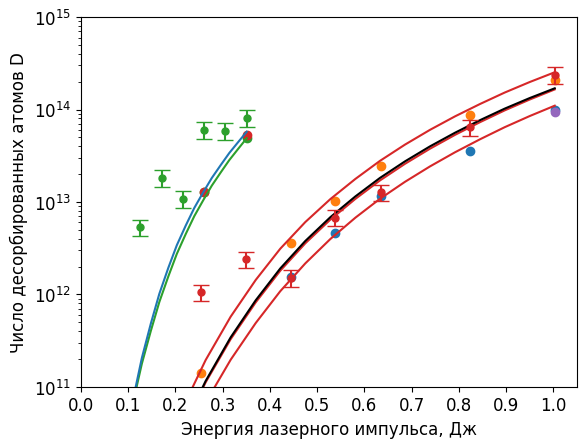

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re

params = {
    "font.size": 12,
}
plt.rcParams.update(params)


def get_data_prof(folder):
    data = []
    for filename in os.listdir(folder):
        if filename.startswith("profiles"):
            file = open(folder + filename)
            header = file.readline().split("\n")[0]
            file.close()
            header = re.sub("[+]", "", header)

            match_number = re.compile("-?\ *[0-9]+\.?[0-9]*(?:[Ee]\ *-?\ *[0-9]+)?")
            floats = [float(x) for x in re.findall(match_number, header)]
            E = float(floats[0])
            desorbed = float(floats[1])
            data.append([E, desorbed])

    data = np.array(data)
    return data[data[:, 0].argsort()]


def get_data(name, folder, Es, rs):

    fluences = []
    for E in Es:
        ints = []

        for r in rs:

            data = np.loadtxt(
                folder + f"flux_{name}_E{E:.3f}_r{r:.2e}.csv", skiprows=1, delimiter=","
            )
            flux = -np.array(data[:, 1])
            t = np.array(data[:, 0])

            int = np.trapz(flux, x=t)
            ints.append(int)

        ints = np.array(ints)
        fluence = np.trapz(2 * np.pi * rs * ints, x=rs)

        fluences.append(fluence)

    return fluences


"""data_1 = get_data_prof("./results_250us_new1/")

plt.plot(
    data_1[:, 0],
    np.array(data_1[:, 1]),
    color="tab:green",
    label="Моделирование: 170 мкс",
)"""

data_1 = get_data_prof("./results_250us_new1/")

plt.plot(
    data_1[:, 0],
    np.array(data_1[:, 1]),
    color="tab:green",
    label="Моделирование: 170 мкс",
)

data_1 = get_data_prof("./results_250us_upd/")

plt.plot(
    data_1[:, 0],
    data_1[:, 1],
    color="tab:blue",
    label="Моделирование: 170 мкс",
)

exp_data = np.loadtxt("../experimental_data/170 us.csv", skiprows=1, delimiter=",")

plt.errorbar(
    exp_data[:, 0],
    exp_data[:, 1],
    yerr=exp_data[:, 1] * 0.20,
    fmt="o",
    markersize=5,
    capsize=6,
    label="Эксперимент: 170 мкс",
    color="tab:green",
)

"""energies_sim = 1.003 * np.linspace(0, 1, 20)
rs = np.linspace(0, 1.5e-3, 50, endpoint=True)
sim_data = get_data("1ms", folder, energies_sim, rs)

plt.plot(energies_sim, sim_data, label="Моделирование: 1 мс", color="tab:red", lw=2)"""

data_1 = get_data_prof("./results_1ms_new/")

plt.plot(
    data_1[:, 0],
    np.array(data_1[:, 1]),
    color="tab:red",
    label="Моделирование: 1 мс",
)

data_1 = get_data_prof("./results_1ms_new1/")

plt.plot(
    data_1[:, 0],
    np.array(data_1[:, 1]),
    color="tab:red",
    label="Моделирование: 1 мс",
)

data_1 = get_data_prof("./results_1ms_new2/")

plt.plot(
    data_1[:, 0],
    np.array(data_1[:, 1]),
    color="tab:red",
    label="Моделирование: 1 мс",
)

data_1 = get_data_prof("./results_1ms_corrected/")

plt.plot(
    data_1[:, 0],
    np.array(data_1[:, 1]),
    color="black",
    label="Моделирование: 1 мс",
)

exp_data = np.loadtxt("../experimental_data/1 ms.csv", skiprows=1, delimiter=",")

plt.errorbar(
    exp_data[:, 0],
    exp_data[:, 1],
    yerr=exp_data[:, 1] * 0.20,
    fmt="o",
    markersize=5,
    capsize=6,
    label="Эксперимент: 1 мс",
    color="tab:red",
)

"""energies_sim = 0.351 * np.linspace(0, 1, 20)
sim_data = get_data("250us", folder, energies_sim, rs)

plt.plot(
    energies_sim, sim_data, label="Моделирование: 170 мкс", color="tab:green", lw=2
)"""


plt.yscale("log")
plt.xlim(0.05, 1.05)
plt.xticks([i / 10 for i in range(0, 11)])
plt.ylim(1e11, 1e15)
plt.ylabel(r"Число десорбированных атомов D")
plt.xlabel("Энергия лазерного импульса, Дж")

# plt.legend(loc="upper left", fontsize=10)

plt.scatter(
    [0.16, 0.255, 0.444, 0.53771, 0.636, 0.823, 1.003],
    [4.77318e09, 5.6266e10, 1.54911e12, 4.63213e12, 1.156e13, 3.60e13, 9.793e13],
)

plt.scatter(
    [0.16, 0.255, 0.444, 0.53771, 0.636, 0.823, 1.003],
    [4.77318e09, 1.40969e11, 3.6248e12, 1.0359e13, 2.475e13, 8.76663e13, 2.103e14],
)

plt.scatter([0.261, 0.351], [1.26933e13, 4.92834e13])
plt.scatter([0.261, 0.351], [1.26933e13, 5.32e13])
# plt.savefig("Сравнение.png", dpi=500, bbox_inches="tight", pad_inches=0.05)

plt.scatter(1.003, 9.496e13)
plt.show()


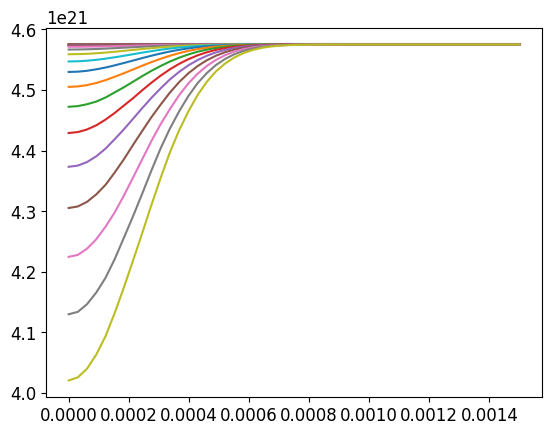

In [15]:
for i in range(2,21):
    E = 1.003 * (i-1)/19
    ret = np.loadtxt(f'./results_1ms_corrected/profiles_1ms_E{E:.3f}.txt', delimiter=",", skiprows=1)

    plt.plot(ret[:,0],ret[:,1])
plt.show()